In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

from hcc_multimodal.baselines.config import MODELS_LR
from hcc_multimodal.baselines.data import add_rfs_columns
from hcc_multimodal.baselines.transforms import DataType
from hcc_multimodal.baselines.evaluation import (
    run_cv_experiment,
    plot_cv_results,
    DeseqCPMSelector,
    apply_selector_before_cv,
)

warnings.filterwarnings("ignore")

In [3]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
RFS_YEAR = 2
CV_N_FOLDS = 3

ROOT = Path().resolve().parents[1]
OUTPUT_DIR = ROOT / "reports" / "0504" / "ensemble_2y_lr"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# Clinical
clinical_data = pd.read_csv(
    ROOT / "data/Clinical/2025_Nov_18_ICL_Resection_Clinical_Outcome_soramic_format.csv"
).dropna(how="all")
clinical_data = add_rfs_columns(clinical_data)

# Arterial radiomics
arterial_data = pd.read_csv(
    ROOT / "data/Radiomics/arterial_radiomics.csv"
).dropna(how="all")
arterial_data["SID"] = (
    arterial_data["Scan name"].str.replace(r"\.nii\.gz$", "", regex=True).astype(int)
)
arterial_data = arterial_data.drop(columns=["Scan name", "VOI name", "Scan path", "VOI path"])

# RNA-seq
rna_raw = pd.read_csv(ROOT / "data/RNA_seq/Matrix_output_radiology_only.csv").dropna(how="all")
gene_symbols = rna_raw["Gene Symbol"]
rna_raw = rna_raw.T.iloc[2:, :]
rna_raw.columns = gene_symbols.values
rna_raw = rna_raw.loc[:, ~pd.isnull(rna_raw.columns)]
rna_raw = rna_raw.loc[:, ~rna_raw.columns.duplicated()]
rna_raw = rna_raw.apply(pd.to_numeric, errors="coerce")
rna_raw.index = rna_raw.index.astype(int)
rna_raw = rna_raw.rename_axis("SID").reset_index()

print(f"Arterial features: {arterial_data.shape[1] - 1}, patients: {len(arterial_data)}")
print(f"RNA-seq genes: {rna_raw.shape[1] - 1}, patients: {len(rna_raw)}")

Arterial features: 4132, patients: 60
RNA-seq genes: 50986, patients: 60


In [5]:
y_col = f"rfs_{RFS_YEAR}year"

arterial_rfs = arterial_data.merge(clinical_data[["SID", y_col]], on="SID").set_index("SID")
rna_rfs = rna_raw.merge(clinical_data[["SID", y_col]], on="SID").set_index("SID")

# Restrict to common, labeled samples in a consistent order
common_sids = arterial_rfs.index.intersection(rna_rfs.index)
y_common = arterial_rfs.loc[common_sids, y_col].dropna()
common_sids = y_common.index  # drop any NaN-label rows

arterial_rfs = arterial_rfs.loc[common_sids]
rna_rfs = rna_rfs.loc[common_sids]

print(f"{RFS_YEAR}y RFS — common labeled patients: {len(common_sids)}, positives: {int(y_common.sum())}")

2y RFS — common labeled patients: 54, positives: 26


In [6]:
# Radiomics: SelectKBest F-score k=100, before CV
X_rad = arterial_rfs.drop(columns=[y_col])
x_cols_rad = {col: DataType.CONTINUOUS for col in X_rad}
X_cv_rad, y_cv, x_cols_cv_rad, cv_kwargs_rad = apply_selector_before_cv(
    X_rad, y_common, x_cols_rad, SelectKBest(f_classif, k=100),
    selector_first=False, label=f"Radiomics {RFS_YEAR}y",
)

# RNA-seq: DeseqCPMSelector padj<0.05 min_features=20, before CV
X_rna = rna_rfs.drop(columns=[y_col])
x_cols_rna = {col: DataType.CONTINUOUS for col in X_rna}
X_cv_rna, _, x_cols_cv_rna, cv_kwargs_rna = apply_selector_before_cv(
    X_rna, y_common, x_cols_rna, DeseqCPMSelector(pvalue=0.05, min_features=20),
    selector_first=True, label=f"RNA-seq {RFS_YEAR}y",
)

[Radiomics 2y] selector applied before CV: 100 features
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.



Fitting dispersions...


... done in 1.50 seconds.

Fitting dispersion trend curve...


... done in 0.27 seconds.

Fitting MAP dispersions...


...

... done in 0.92 seconds.

Fitting LFCs...


... done in 0.72 seconds.



Running Wald tests...


Log2 fold change & Wald test p-value: condition 1 vs 0
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
TSPAN6       210.977458       -0.825635  1.414003 -0.583899  0.559288   
TNMD          29.371480        0.430522  1.857437  0.231783  0.816707   
DPM1         196.474521       -0.353054  1.338852 -0.263699  0.792012   
SCYL3        174.043340       -0.051822  1.199737 -0.043195  0.965546   
C1orf112     101.960002       -0.252070  1.369402 -0.184073  0.853956   
...                 ...             ...       ...       ...       ...   
AC003043.2     0.457649       -0.226790  1.254712 -0.180750  0.856564   
AC135068.11    3.929069        2.930442  2.149668  1.363206  0.172817   
AL356417.3     3.328129        0.057699  0.844483  0.068325  0.945527   
AC104389.6     0.041225       -0.363888  3.053434 -0.119173  0.905138   
AP000646.1     0.000000        0.000000  0.000000  0.000000       NaN   

                 padj  
TSPAN6       0.999959  
TNMD         0.99995

... done in 0.77 seconds.



In [7]:
# Best model: LR C=1 L1 (best in both modalities for 2y before-CV)
MODEL_LR = {k: v for k, v in MODELS_LR.items() if k == "LR_C=1"}

_, fold_df_rad = run_cv_experiment(
    X_cv_rad, y_cv, x_cols_cv_rad, f"Radiomics {RFS_YEAR}y",
    models=MODEL_LR, n_splits=CV_N_FOLDS, return_proba=True, **cv_kwargs_rad,
)
_, fold_df_rna = run_cv_experiment(
    X_cv_rna, y_cv, x_cols_cv_rna, f"RNA-seq {RFS_YEAR}y",
    models=MODEL_LR, n_splits=CV_N_FOLDS, return_proba=True, **cv_kwargs_rna,
)

[Radiomics 2y]  n=54  positives=26  features=100
[RNA-seq 2y]  n=54  positives=26  features=20


In [8]:
rows_rad = fold_df_rad[fold_df_rad["model"] == "LR_C=1"].set_index("fold")
rows_rna = fold_df_rna[fold_df_rna["model"] == "LR_C=1"].set_index("fold")

fold_aucs_ens, fold_aucs_rad, fold_aucs_rna = [], [], []
for fold_i in range(1, CV_N_FOLDS + 1):
    r_rad = rows_rad.loc[fold_i]
    r_rna = rows_rna.loc[fold_i]
    assert r_rad["test_indices"] == r_rna["test_indices"], f"Fold {fold_i} indices mismatch"
    ens_proba = (np.array(r_rad["test_proba"]) + np.array(r_rna["test_proba"])) / 2
    y_test = y_cv.loc[r_rad["test_indices"]]
    auc_ens = roc_auc_score(y_test, ens_proba)
    fold_aucs_ens.append(auc_ens)
    fold_aucs_rad.append(r_rad["test_auc"])
    fold_aucs_rna.append(r_rna["test_auc"])
    print(f"Fold {fold_i}: ensemble={auc_ens:.3f}  radiomics={r_rad['test_auc']:.3f}  rna={r_rna['test_auc']:.3f}")

print(f"\nMean AUC — ensemble={np.mean(fold_aucs_ens):.3f}  radiomics={np.mean(fold_aucs_rad):.3f}  rna={np.mean(fold_aucs_rna):.3f}")

results = pd.DataFrame({
    "fold": range(1, CV_N_FOLDS + 1),
    "ensemble": fold_aucs_ens,
    "radiomics": fold_aucs_rad,
    "rna_seq": fold_aucs_rna,
})
results.loc[len(results)] = ["mean", np.mean(fold_aucs_ens), np.mean(fold_aucs_rad), np.mean(fold_aucs_rna)]
display(results)
results.to_csv(OUTPUT_DIR / "ensemble_2y_lr_auc.csv", index=False)

Fold 1: ensemble=0.912  radiomics=0.825  rna=0.913
Fold 2: ensemble=0.926  radiomics=0.901  rna=0.840
Fold 3: ensemble=0.815  radiomics=0.667  rna=0.790

Mean AUC — ensemble=0.884  radiomics=0.798  rna=0.847


,fold,ensemble,radiomics,rna_seq
0,1,0.912500,0.825000,0.912500
1,2,0.925926,0.901235,0.839506
2,3,0.814815,0.666667,0.790123
3,mean,0.884414,0.797634,0.847377


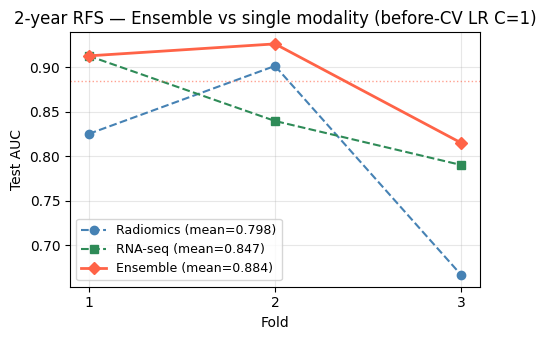

In [9]:
fig, ax = plt.subplots(figsize=(5, 3.5))
folds = range(1, CV_N_FOLDS + 1)
ax.plot(folds, fold_aucs_rad, "o--", color="steelblue", label=f"Radiomics (mean={np.mean(fold_aucs_rad):.3f})")
ax.plot(folds, fold_aucs_rna, "s--", color="seagreen", label=f"RNA-seq (mean={np.mean(fold_aucs_rna):.3f})")
ax.plot(folds, fold_aucs_ens, "D-", color="tomato", linewidth=2, label=f"Ensemble (mean={np.mean(fold_aucs_ens):.3f})")
ax.axhline(np.mean(fold_aucs_ens), color="tomato", linestyle=":", linewidth=1, alpha=0.6)
ax.set_xlabel("Fold")
ax.set_ylabel("Test AUC")
ax.set_title(f"{RFS_YEAR}-year RFS — Ensemble vs single modality (before-CV LR C=1)")
ax.set_xticks(list(folds))
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ensemble_2y_lr_auc.png", bbox_inches="tight", dpi=150)
plt.show()